# EDA for CHGH dataset

In [24]:
!nvidia-smi

Sun Jul  2 09:05:28 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.141.03   Driver Version: 470.141.03   CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-SXM2...  On   | 00000000:0B:00.0 Off |                    0 |
| N/A   30C    P0    47W / 163W |   7720MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

## Setup Environment

In [25]:
import matplotlib
%matplotlib inline

# sync python module
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import Library

In [26]:
import sys
import os
# set package path
sys.path.append("/nfs/Workspace/CardiacSeg")

from monai.data import CacheDataset, DatasetSummary, DataLoader
from monai.transforms import (
    AddChanneld,
    Compose,
    LoadImaged,
    Orientationd,
    RandFlipd,
    RandCropByPosNegLabeld,
    RandShiftIntensityd,
    ScaleIntensityRanged,
    Spacingd,
    RandRotate90d,
    ToTensord,
    SqueezeDimd
)
from monai.utils import first

import matplotlib.pyplot as plt
import pandas as pd

from data_utils.data_loader_utils import load_data_dict_json, split_data_dicts
from datasets.chgh_dataset import get_data_dicts
from datasets.label_dataset import get_multiple_label_data_dicts, multi_label_to_label_pred_data_dicts
from data_utils.visualization import show_img_lbl
from data_utils.utils import get_data_info, get_pids_by_data_dicts
from data_utils.io import load_json, save_json
from expers.preprocess import get_rel_data_dicts

## Prepare data dicts

In [27]:
from pprint import pprint


def get_data_by_idxs(data_dicts, idxs):
    return get_rel_data_dicts([data_dicts[i] for i in idxs])

data_dicts_json = os.path.join('/nfs/Workspace/CardiacSeg', 'exps', 'data_dicts', 'chgh', 'exp_b7_9.json')
data_dir = '/nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2'

data_dicts = get_data_dicts(data_dir)
pids = get_pids_by_data_dicts(data_dicts)


tr_idx = [5, 9, 10, 12, 13, 14, 18, 20, 21]
val_idx = [0, 16, 17]
tt_idx = [1, 15, 19]

out_data_dicts = {
    'train' : get_data_by_idxs(data_dicts, tr_idx),
    'val' : get_data_by_idxs(data_dicts, val_idx),
    'test' : get_data_by_idxs(data_dicts, tt_idx)
}

pprint(out_data_dicts)
# save_json(out_data_dicts, data_dicts_json)

{'test': [{'image': 'pid_02/pid_02.nii.gz', 'label': 'pid_02/pid_02_gt.nii.gz'},
          {'image': 'pid_106/pid_106.nii.gz',
           'label': 'pid_106/pid_106_gt.nii.gz'},
          {'image': 'pid_1000/pid_1000.nii.gz',
           'label': 'pid_1000/pid_1000_gt.nii.gz'}],
 'train': [{'image': 'pid_08/pid_08.nii.gz',
            'label': 'pid_08/pid_08_gt.nii.gz'},
           {'image': 'pid_27/pid_27.nii.gz',
            'label': 'pid_27/pid_27_gt.nii.gz'},
           {'image': 'pid_30/pid_30.nii.gz',
            'label': 'pid_30/pid_30_gt.nii.gz'},
           {'image': 'pid_52/pid_52.nii.gz',
            'label': 'pid_52/pid_52_gt.nii.gz'},
           {'image': 'pid_56/pid_56.nii.gz',
            'label': 'pid_56/pid_56_gt.nii.gz'},
           {'image': 'pid_57/pid_57.nii.gz',
            'label': 'pid_57/pid_57_gt.nii.gz'},
           {'image': 'pid_110/pid_110.nii.gz',
            'label': 'pid_110/pid_110_gt.nii.gz'},
           {'image': 'pid_1002/pid_1002.nii.gz',
           

## Show data info

In [28]:
data_dicts_json =  '/nfs/Workspace/CardiacSeg/exps/data_dicts/chgh/exp_b7_9.json'
data_dir = '/nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2'
tr_ds, val_ds, tt_ds = load_data_dict_json(data_dir, data_dicts_json)
ds = [*tr_ds, *val_ds, *tt_ds]

load json from /nfs/Workspace/CardiacSeg/exps/data_dicts/chgh/exp_b7_9.json
train files (9): ['pid_08', 'pid_27', 'pid_30', 'pid_52', 'pid_56', 'pid_57', 'pid_110', 'pid_1002', 'pid_1003']
val files (3): ['pid_08_1', 'pid_107', 'pid_108']
test files (3): ['pid_02', 'pid_106', 'pid_1000']


monai.transforms.io.dictionary LoadImaged.__init__:image_only: Current default value of argument `image_only=False` has been deprecated since version 1.1. It will be changed to `image_only=True` in version 1.3.


pid: pid_08
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_08/pid_08.nii.gz
img shape: [512, 512, 341]
img spacing: [0.38085938, 0.38085938, 0.5]
lbl shape: [512, 512, 341]
lbl spacing: [0.38085938, 0.38085938, 0.5]
lbl ids: [0. 1.]


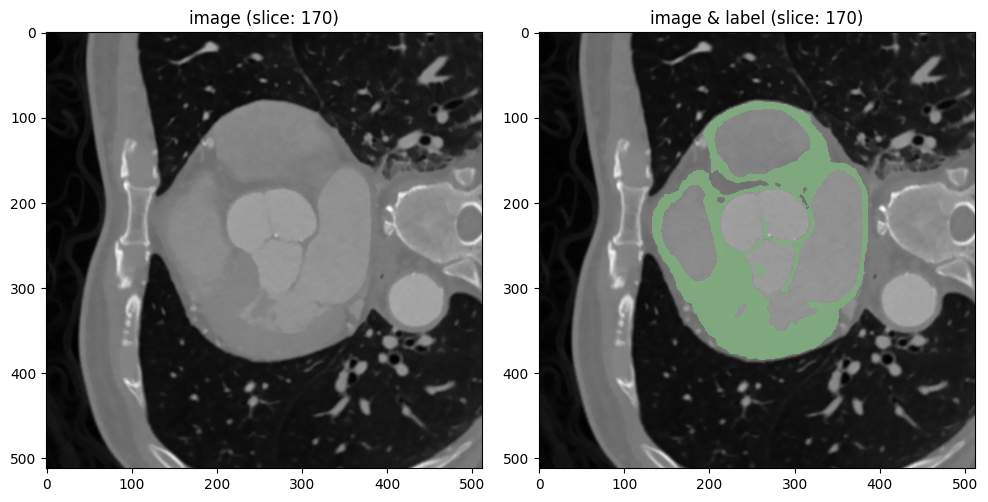

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_27
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_27/pid_27.nii.gz
img shape: [512, 512, 331]
img spacing: [0.3828125, 0.3828125, 0.5]
lbl shape: [512, 512, 331]
lbl spacing: [0.3828125, 0.3828125, 0.5]
lbl ids: [0. 1.]


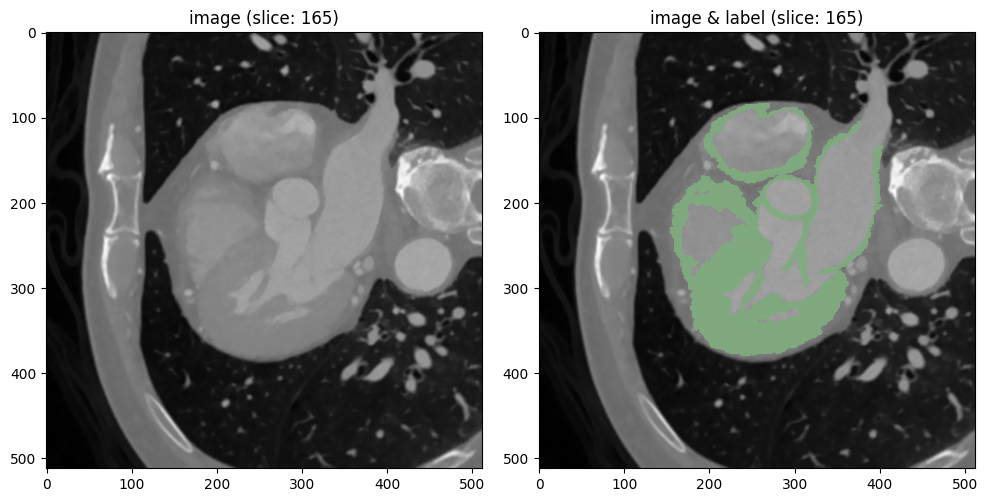

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_30
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_30/pid_30.nii.gz
img shape: [512, 512, 274]
img spacing: [0.3515625, 0.3515625, 0.5]
lbl shape: [512, 512, 274]
lbl spacing: [0.3515625, 0.3515625, 0.5]
lbl ids: [0. 1.]


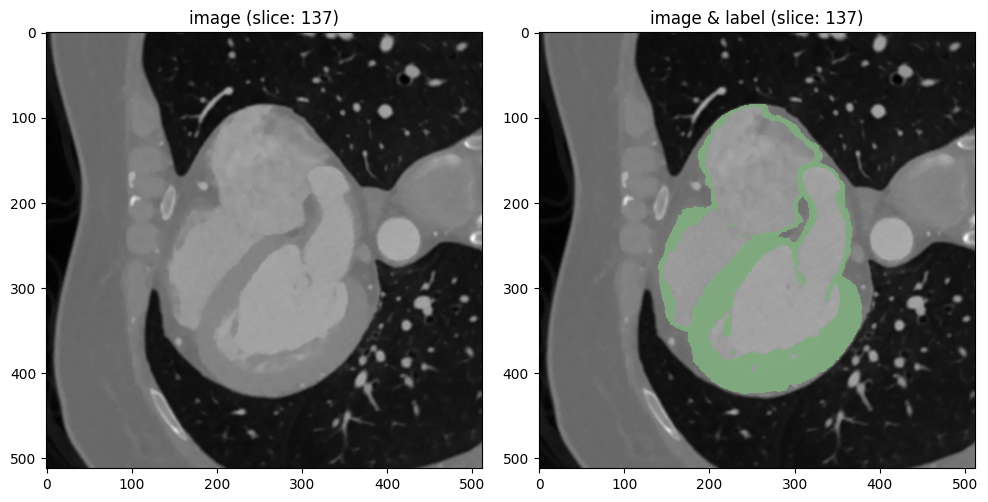

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_52
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_52/pid_52.nii.gz
img shape: [512, 512, 275]
img spacing: [0.34375, 0.34375, 0.5]
lbl shape: [512, 512, 275]
lbl spacing: [0.34375, 0.34375, 0.5]
lbl ids: [0. 1.]


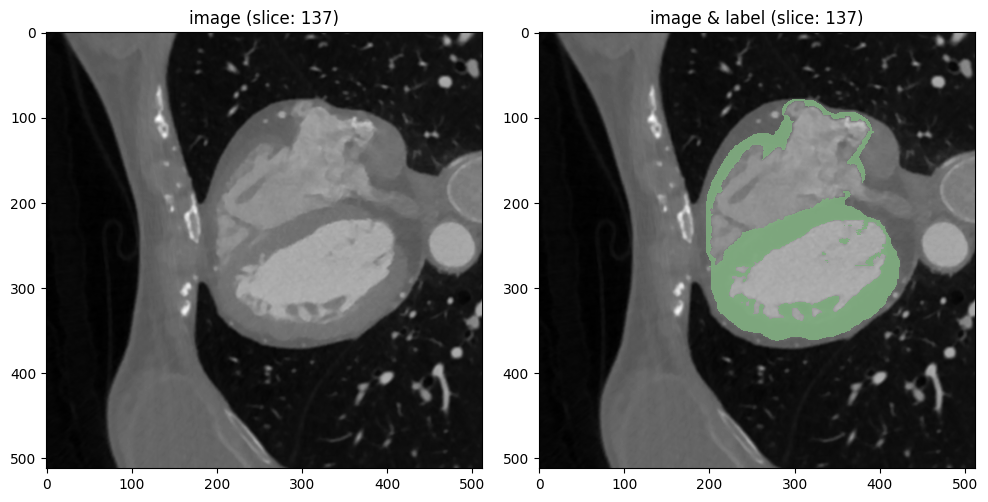

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_56
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_56/pid_56.nii.gz
img shape: [512, 512, 297]
img spacing: [0.36523438, 0.36523438, 0.5]
lbl shape: [512, 512, 297]
lbl spacing: [0.36523438, 0.36523438, 0.5]
lbl ids: [0. 1.]


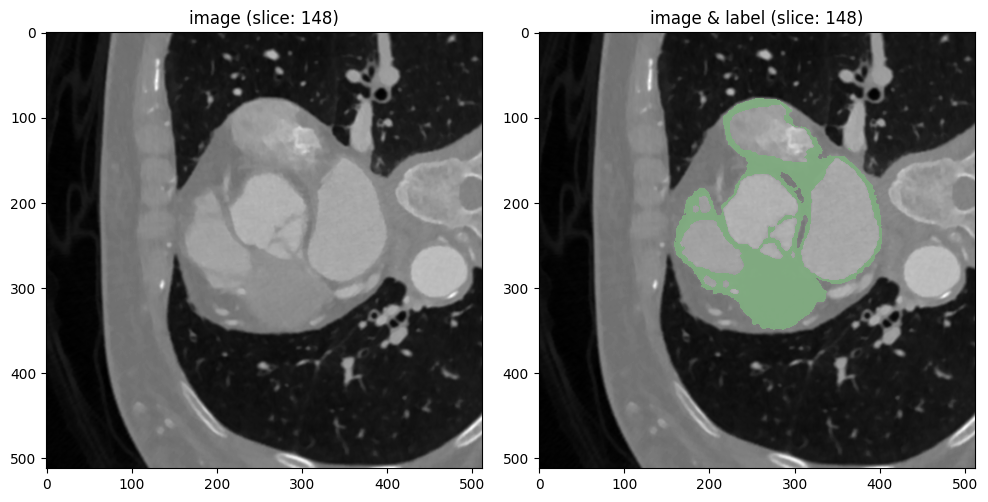

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_57
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_57/pid_57.nii.gz
img shape: [512, 512, 411]
img spacing: [0.47851562, 0.47851562, 0.4]
lbl shape: [512, 512, 411]
lbl spacing: [0.47851562, 0.47851562, 0.4]
lbl ids: [0. 1.]


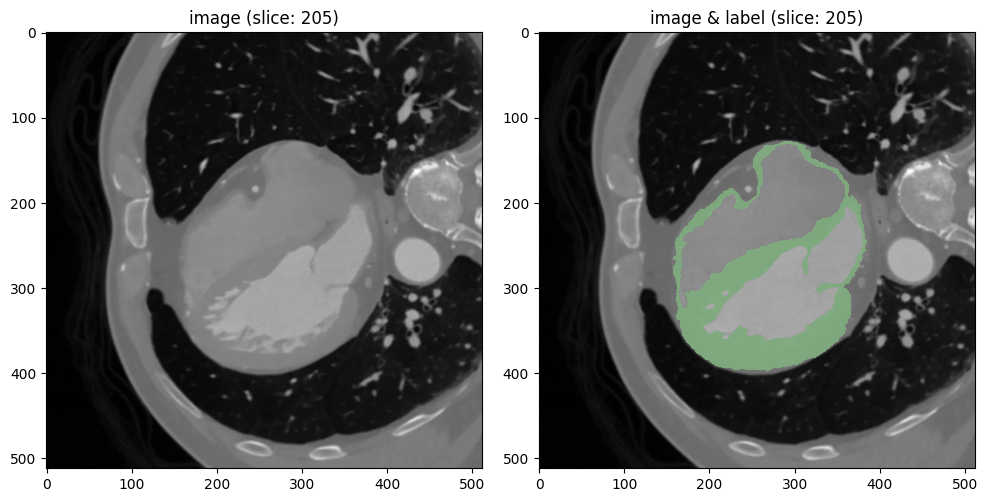

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_110
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_110/pid_110.nii.gz
img shape: [512, 512, 366]
img spacing: [0.37890625, 0.37890625, 0.4]
lbl shape: [512, 512, 366]
lbl spacing: [0.37890625, 0.37890625, 0.4]
lbl ids: [0. 1.]


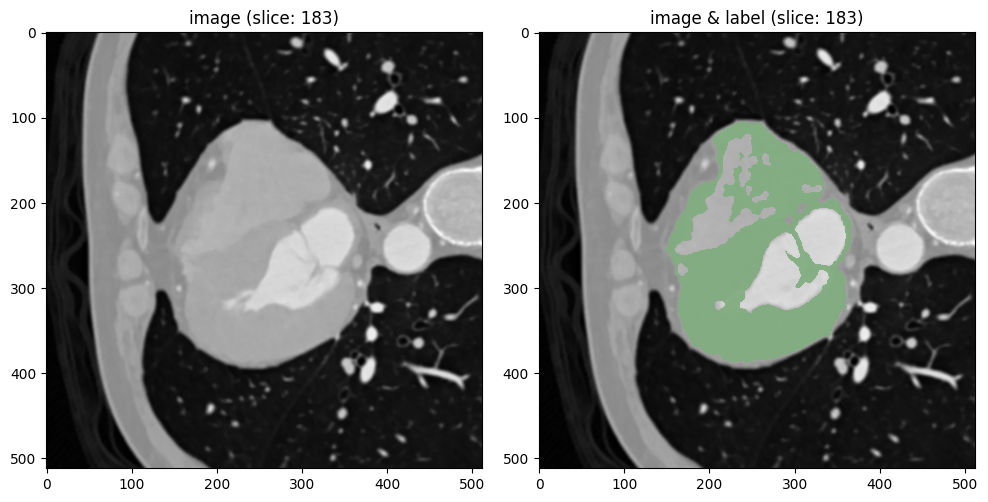

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_1002
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_1002/pid_1002.nii.gz
img shape: [512, 512, 317]
img spacing: [0.40625, 0.40625, 0.5]
lbl shape: [512, 512, 317]
lbl spacing: [0.40625, 0.40625, 0.5]
lbl ids: [0. 1.]


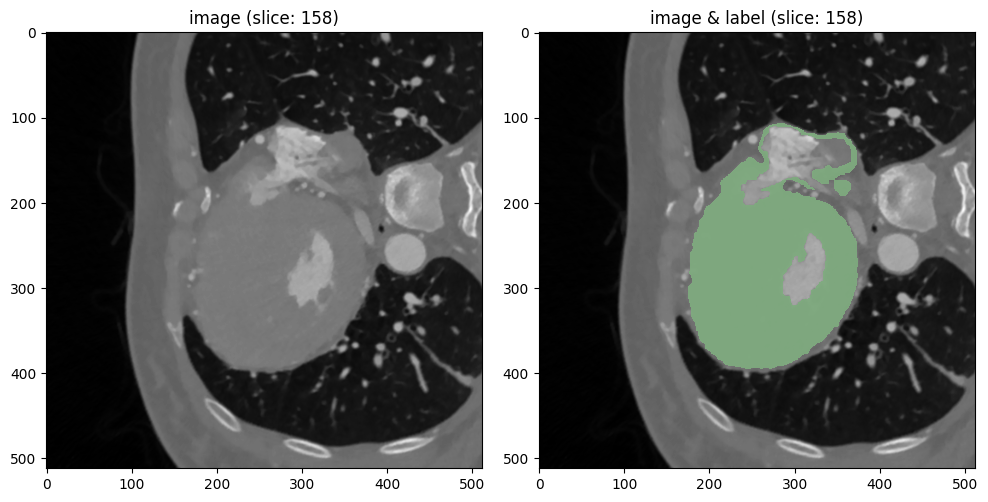

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_1003
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_1003/pid_1003.nii.gz
img shape: [512, 512, 317]
img spacing: [0.40625, 0.40625, 0.5]
lbl shape: [512, 512, 317]
lbl spacing: [0.40625, 0.40625, 0.5]
lbl ids: [0. 1.]


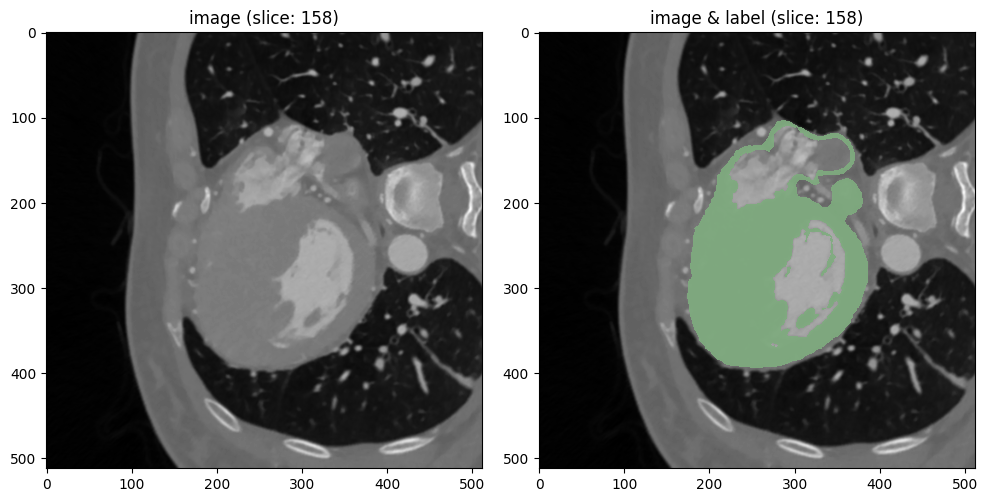

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_08_1
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_08_1/pid_08_1.nii.gz
img shape: [512, 512, 341]
img spacing: [0.41601562, 0.41601562, 0.5]
lbl shape: [512, 512, 341]
lbl spacing: [0.41601562, 0.41601562, 0.5]
lbl ids: [0. 1.]


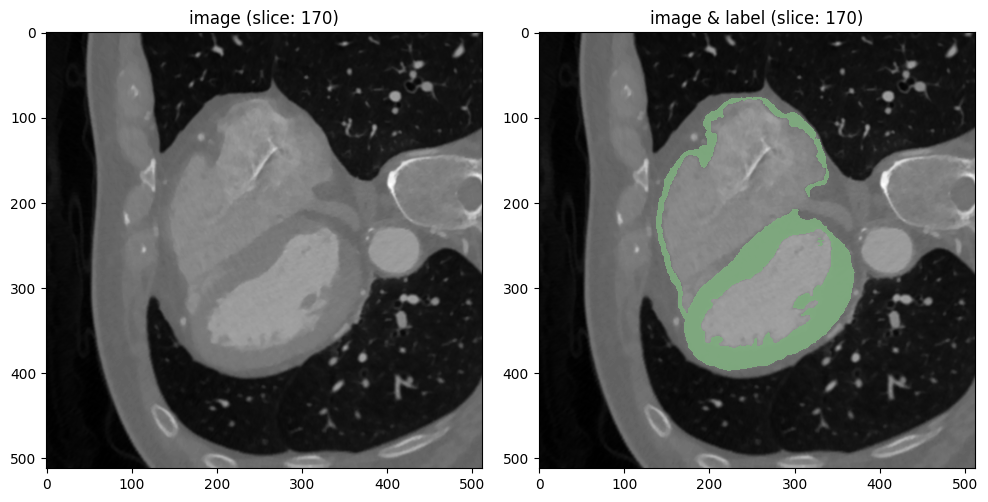

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_107
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_107/pid_107.nii.gz
img shape: [512, 512, 376]
img spacing: [0.33203125, 0.33203125, 0.4]
lbl shape: [512, 512, 376]
lbl spacing: [0.33203125, 0.33203125, 0.4]
lbl ids: [0. 1.]


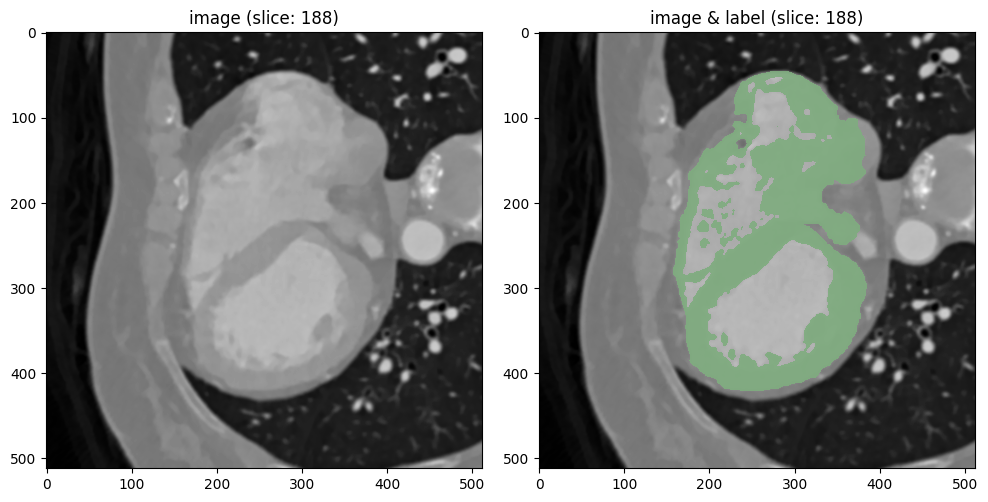

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_108
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_108/pid_108.nii.gz
img shape: [512, 512, 267]
img spacing: [0.3359375, 0.3359375, 0.5]
lbl shape: [512, 512, 267]
lbl spacing: [0.3359375, 0.3359375, 0.5]
lbl ids: [0. 1.]


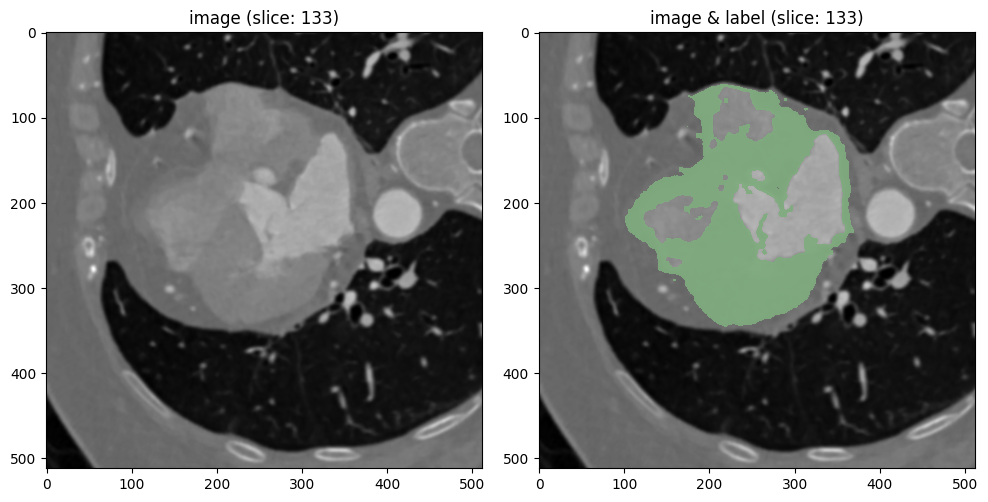

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_02
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_02/pid_02.nii.gz
img shape: [512, 512, 429]
img spacing: [0.38085938, 0.38085938, 0.4]
lbl shape: [512, 512, 429]
lbl spacing: [0.38085938, 0.38085938, 0.4]
lbl ids: [0. 1.]


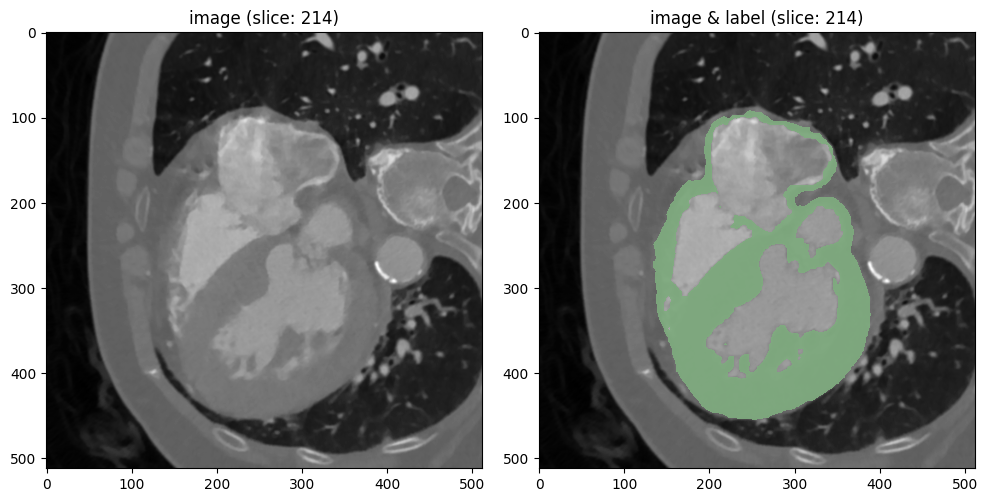

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_106
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_106/pid_106.nii.gz
img shape: [512, 512, 403]
img spacing: [0.42382812, 0.42382812, 0.4]
lbl shape: [512, 512, 403]
lbl spacing: [0.42382812, 0.42382812, 0.4]
lbl ids: [0. 1.]


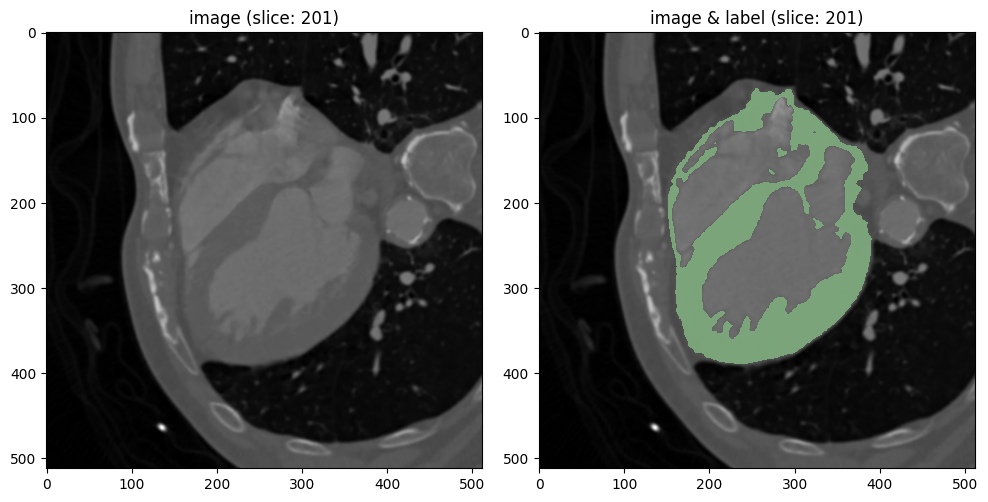

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_1000
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_1000/pid_1000.nii.gz
img shape: [512, 512, 357]
img spacing: [0.36914062, 0.36914062, 0.4]
lbl shape: [512, 512, 357]
lbl spacing: [0.36914062, 0.36914062, 0.4]
lbl ids: [0. 1.]


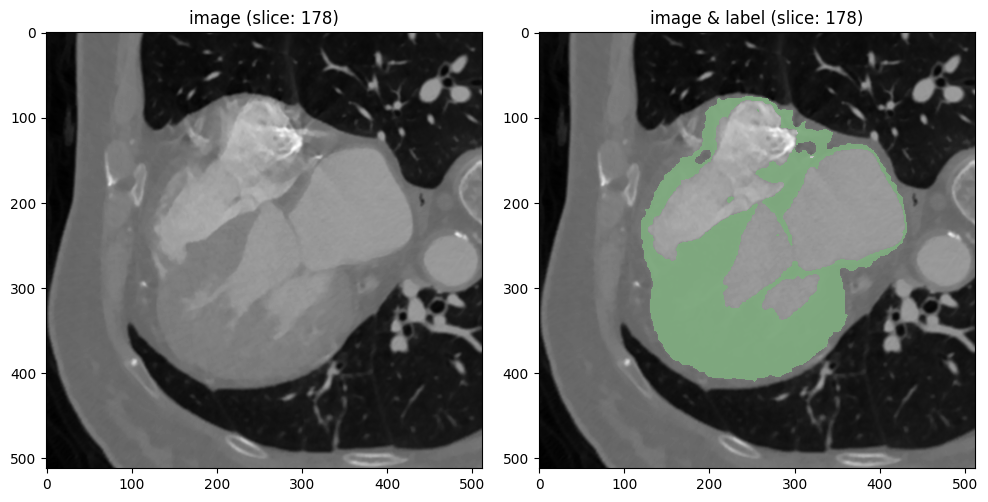

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.


In [29]:
data_info_df = get_data_info(ds)

In [32]:
data_info_df

,pid,img_shape,img_space,lbl_shape,lbl_space,lbl_ids
0,pid_08,"[512, 512, 341]","[0.38085938, 0.38085938, 0.5]","[512, 512, 341]","[0.38085938, 0.38085938, 0.5]","[0.0, 1.0]"
1,pid_27,"[512, 512, 331]","[0.3828125, 0.3828125, 0.5]","[512, 512, 331]","[0.3828125, 0.3828125, 0.5]","[0.0, 1.0]"
2,pid_30,"[512, 512, 274]","[0.3515625, 0.3515625, 0.5]","[512, 512, 274]","[0.3515625, 0.3515625, 0.5]","[0.0, 1.0]"
3,pid_52,"[512, 512, 275]","[0.34375, 0.34375, 0.5]","[512, 512, 275]","[0.34375, 0.34375, 0.5]","[0.0, 1.0]"
4,pid_56,"[512, 512, 297]","[0.36523438, 0.36523438, 0.5]","[512, 512, 297]","[0.36523438, 0.36523438, 0.5]","[0.0, 1.0]"
5,pid_57,"[512, 512, 411]","[0.47851562, 0.47851562, 0.4]","[512, 512, 411]","[0.47851562, 0.47851562, 0.4]","[0.0, 1.0]"
6,pid_110,"[512, 512, 366]","[0.37890625, 0.37890625, 0.4]","[512, 512, 366]","[0.37890625, 0.37890625, 0.4]","[0.0, 1.0]"
7,pid_1002,"[512, 512, 317]","[0.40625, 0.40625, 0.5]","[512, 512, 317]","[0.40625, 0.40625, 0.5]","[0.0, 1.0]"
8,pid_1003,"[512, 512, 317]","[0.40625, 0.40625, 0.5]","[512, 512, 317]","[0.40625, 0.40625, 0.5]","[0.0, 1.0]"
9,pid_08_1,"[512, 512, 341]","[0.41601562, 0.41601562, 0.5]","[512, 512, 341]","[0.41601562, 0.41601562, 0.5]","[0.0, 1.0]"


In [8]:
data_shape_df = pd.DataFrame(data_info_df['img_shape'].to_list(), columns=['w', 'h', 's'])
print('min:', data_shape_df.min().to_list())
print('max:',data_shape_df.max().to_list())
print('mean:',data_shape_df.mean().to_list())

min: [512, 512, 267]
max: [512, 512, 429]
mean: [512.0, 512.0, 340.1333333333333]


In [9]:
data_space_df = pd.DataFrame(data_info_df['img_space'].to_list(), columns=['x', 'y', 'z'])

min_z = data_space_df[['z']].min().values[0]
max_z = data_space_df[['z']].max().values[0]

min_z_df = data_space_df.loc[data_space_df['z'] == min_z]
max_z_df = data_space_df.loc[data_space_df['z'] == max_z]

print('sp xyz mean:',data_space_df.mean().to_list())
print('sp min xy min z:', min_z_df.min().to_list())
print('sp max xy min z:', min_z_df.max().to_list())
print('sp min xy max z:', max_z_df.min().to_list())
print('sp max xy max z:', max_z_df.max().to_list())

sp xyz mean: [0.3834635317325592, 0.3834635317325592, 0.46000003814697266]
sp min xy min z: [0.33203125, 0.33203125, 0.4000000059604645]
sp max xy min z: [0.478515625, 0.478515625, 0.4000000059604645]
sp min xy max z: [0.3359375, 0.3359375, 0.5]
sp max xy max z: [0.416015625, 0.416015625, 0.5]


## Statcics

In [10]:
base_tf = Compose([
    LoadImaged(keys=['image', 'label']),
    AddChanneld(keys=['image', 'label'])
])

ds = CacheDataset(
    data=tr_ds,
    transform=base_tf
)

monai.transforms.io.dictionary LoadImaged.__init__:image_only: Current default value of argument `image_only=False` has been deprecated since version 1.1. It will be changed to `image_only=True` in version 1.3.
<class 'monai.transforms.utility.dictionary.AddChanneld'>: Class `AddChanneld` has been deprecated since version 0.8. It will be removed in version 1.3. please use MetaTensor data type and monai.transforms.EnsureChannelFirstd instead with `channel_dim='no_channel'`.
monai.transforms.utility.dictionary EnsureChannelFirstd.__init__:meta_keys: Argument `meta_keys` has been deprecated since version 0.9. not needed if image is type `MetaTensor`.
Loading dataset: 100%|██████████| 9/9 [00:41<00:00,  4.58s/it]


In [21]:
# ref: https://arxiv.org/pdf/1904.08128.pdf
s = DatasetSummary(ds)
s.calculate_percentiles(min_percentile=0.5,max_percentile=99.5)
s.calculate_statistics()
data_target_space = s.get_target_spacing()

In [22]:
print('data target space:')
data_target_space

data target space:


(0.380859375, 0.380859375, 0.5)

In [23]:
print('data intensities statcics:')
data_intensities_statcics = pd.DataFrame(
    [[s.data_min, s.data_median, s.data_max, s.data_mean, s.data_std, s.data_min_percentile, s.data_max_percentile]],
    columns=['min', 'med', 'max', 'mean', 'std', 'min_percentile (0.5%)', 'max_percentile (99.5%)']
)
data_intensities_statcics

data intensities statcics:


,min,med,max,mean,std,min_percentile (0.5%),max_percentile (99.5%)
0,-827.0,116.0,1613.0,127.986061,74.365562,-29.0,448.0


## Transform

In [14]:
space = [1.0,1.0,1.0]
a_min = -42 #s.data_min_percentile
a_max = 423 #s.data_max_percentile
transform = Compose(
      [
          LoadImaged(keys=["image", "label"]),
          AddChanneld(keys=["image", "label"]),
          Orientationd(keys=["image", "label"], axcodes="RAS"),
          # Spacingd(
          #     keys=["image", "label"],
          #     pixdim=space,
          #     mode=("bilinear", "nearest"),
          # ),
          ScaleIntensityRanged(
              keys=["image"], a_min=a_min, a_max=a_max, b_min=0.0, b_max=1.0, clip=True
          ),
          SqueezeDimd(keys=["image", "label"]),
          ToTensord(keys=["image", "label"])
      ]
  )

monai.transforms.io.dictionary LoadImaged.__init__:image_only: Current default value of argument `image_only=False` has been deprecated since version 1.1. It will be changed to `image_only=True` in version 1.3.
<class 'monai.transforms.utility.dictionary.AddChanneld'>: Class `AddChanneld` has been deprecated since version 0.8. It will be removed in version 1.3. please use MetaTensor data type and monai.transforms.EnsureChannelFirstd instead with `channel_dim='no_channel'`.
monai.transforms.utility.dictionary EnsureChannelFirstd.__init__:meta_keys: Argument `meta_keys` has been deprecated since version 0.9. not needed if image is type `MetaTensor`.


pid: pid_08
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_08/pid_08.nii.gz
img shape: [512, 512, 341]
img spacing: [0.38085938, 0.38085938, 0.5]
lbl shape: [512, 512, 341]
lbl spacing: [0.38085938, 0.38085938, 0.5]
lbl ids: [0. 1.]


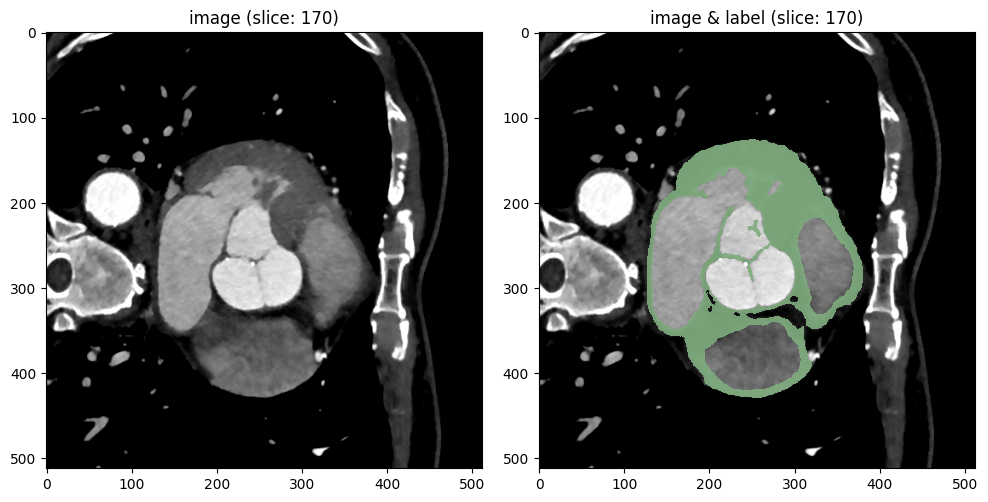

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_27
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_27/pid_27.nii.gz
img shape: [512, 512, 331]
img spacing: [0.3828125, 0.3828125, 0.5]
lbl shape: [512, 512, 331]
lbl spacing: [0.3828125, 0.3828125, 0.5]
lbl ids: [0. 1.]


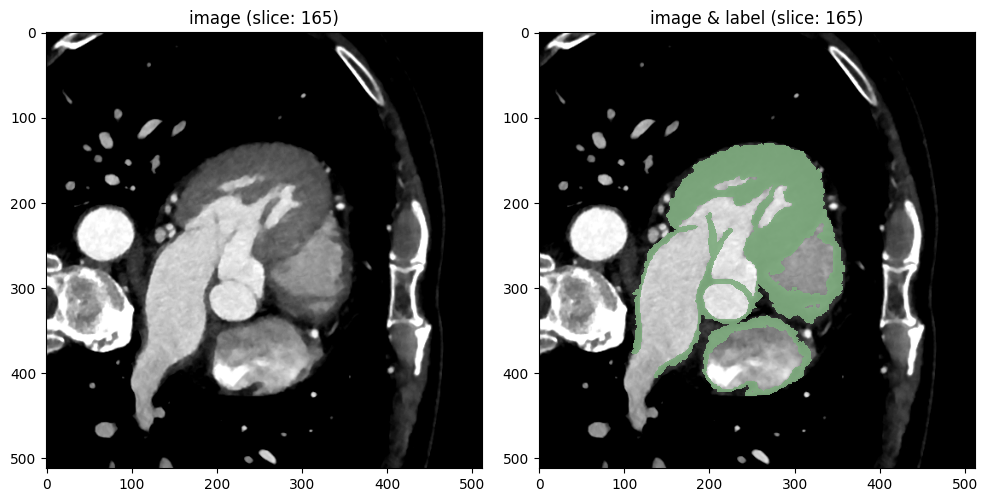

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_30
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_30/pid_30.nii.gz
img shape: [512, 512, 274]
img spacing: [0.3515625, 0.3515625, 0.5]
lbl shape: [512, 512, 274]
lbl spacing: [0.3515625, 0.3515625, 0.5]
lbl ids: [0. 1.]


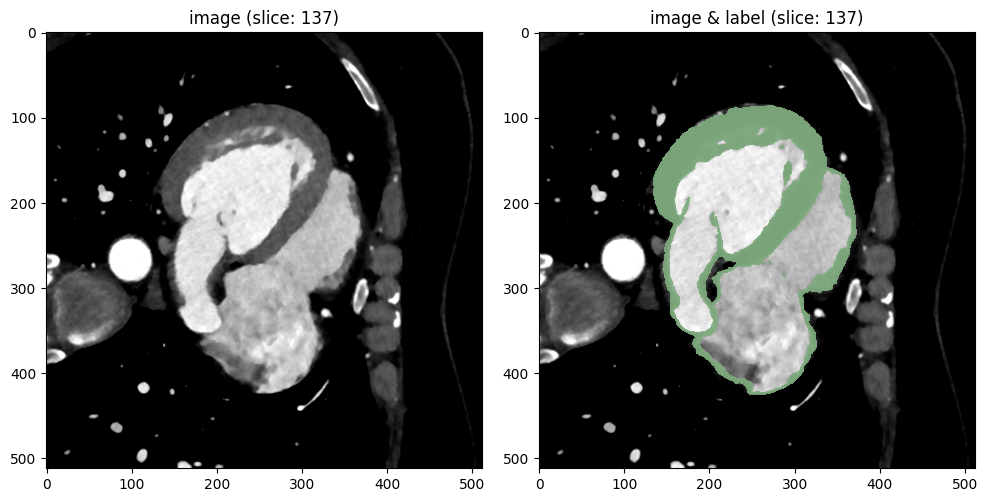

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_52
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_52/pid_52.nii.gz
img shape: [512, 512, 275]
img spacing: [0.34375, 0.34375, 0.5]
lbl shape: [512, 512, 275]
lbl spacing: [0.34375, 0.34375, 0.5]
lbl ids: [0. 1.]


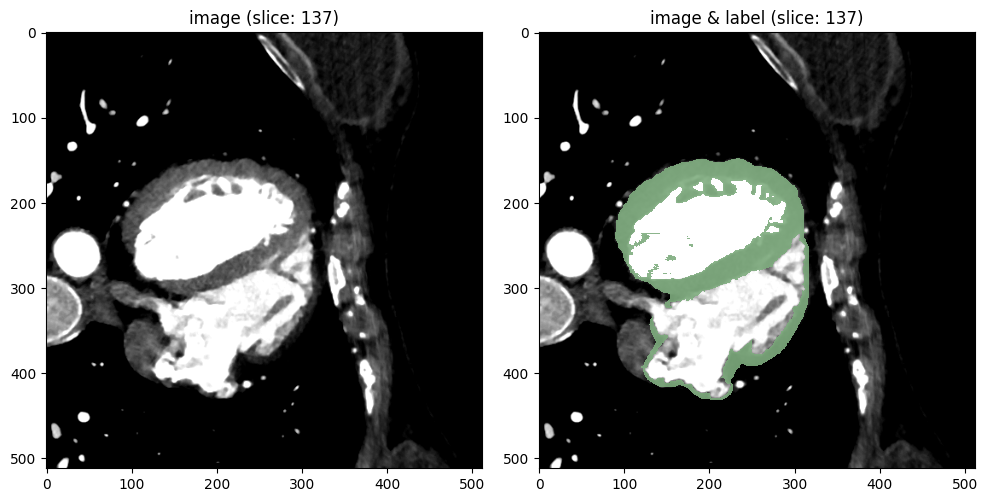

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_56
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_56/pid_56.nii.gz
img shape: [512, 512, 297]
img spacing: [0.36523438, 0.36523438, 0.5]
lbl shape: [512, 512, 297]
lbl spacing: [0.36523438, 0.36523438, 0.5]
lbl ids: [0. 1.]


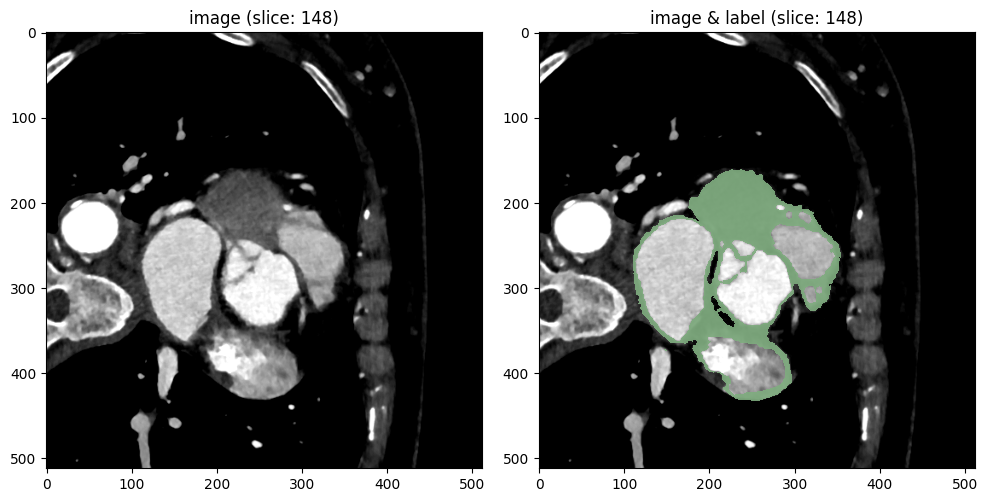

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_57
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_57/pid_57.nii.gz
img shape: [512, 512, 411]
img spacing: [0.47851562, 0.47851562, 0.4]
lbl shape: [512, 512, 411]
lbl spacing: [0.47851562, 0.47851562, 0.4]
lbl ids: [0. 1.]


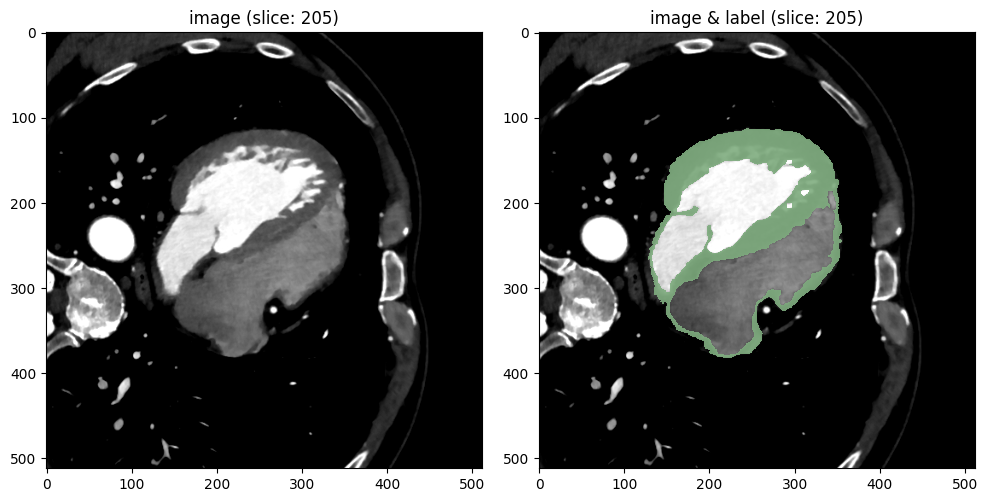

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_110
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_110/pid_110.nii.gz
img shape: [512, 512, 366]
img spacing: [0.37890625, 0.37890625, 0.4]
lbl shape: [512, 512, 366]
lbl spacing: [0.37890625, 0.37890625, 0.4]
lbl ids: [0. 1.]


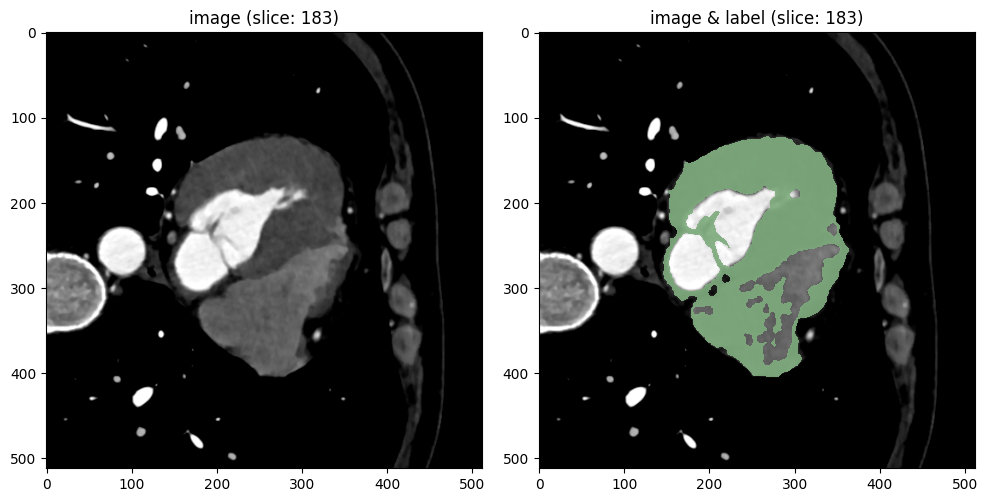

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_1002
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_1002/pid_1002.nii.gz
img shape: [512, 512, 317]
img spacing: [0.40625, 0.40625, 0.5]
lbl shape: [512, 512, 317]
lbl spacing: [0.40625, 0.40625, 0.5]
lbl ids: [0. 1.]


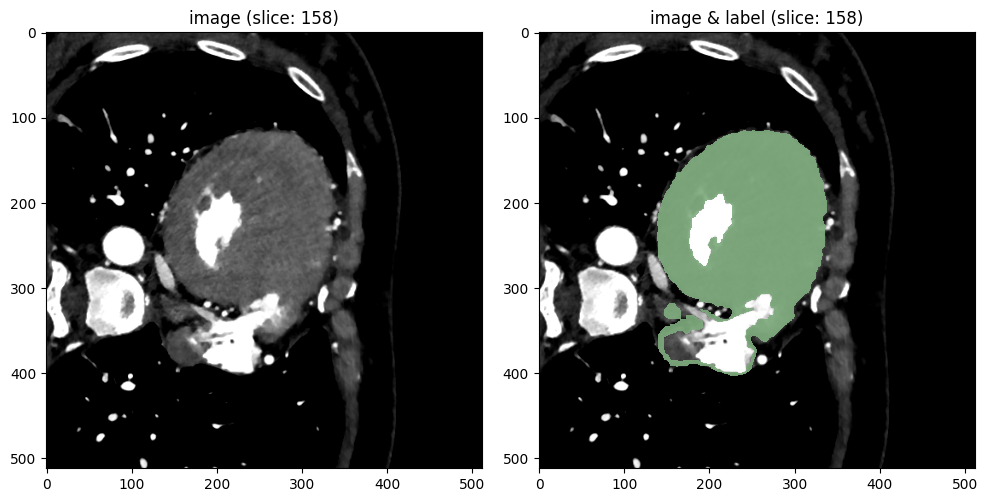

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



pid: pid_1003
file_pth: /nfs/Workspace/CardiacSeg/dataset/chgh/dataset_2/pid_1003/pid_1003.nii.gz
img shape: [512, 512, 317]
img spacing: [0.40625, 0.40625, 0.5]
lbl shape: [512, 512, 317]
lbl spacing: [0.40625, 0.40625, 0.5]
lbl ids: [0. 1.]


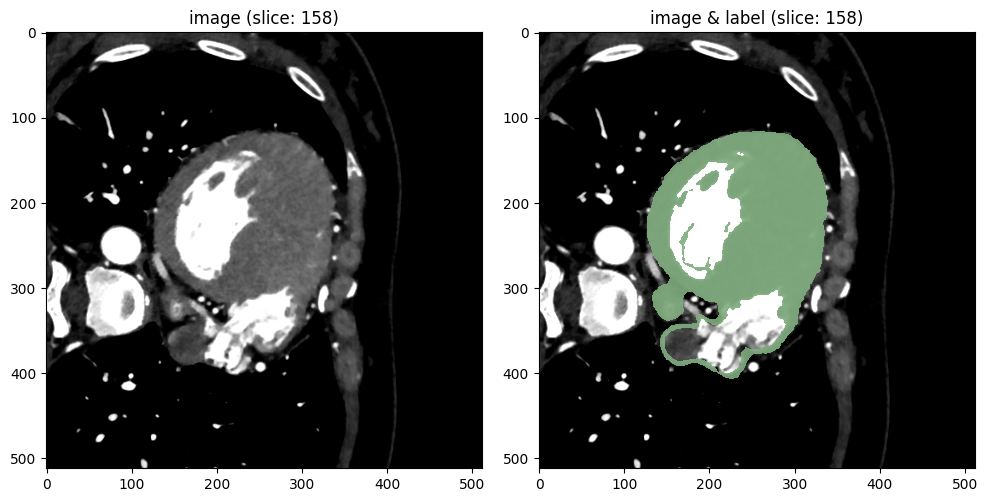

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.


In [15]:
data_info_df = get_data_info(tr_ds, transform)